In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("thyroid_dataset.csv")

In [3]:
df.head()

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured,Outlier_label
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,61.0,6.0,23.0,87.0,26.0,o
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,29.0,15.0,61.0,96.0,64.0,o
2,0.16,0,1,0,0,0,0,0,0,0,...,0,1,0,0,29.0,19.0,58.0,103.0,56.0,o
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,114.0,3.0,24.0,61.0,39.0,o
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,49.0,3.0,5.0,116.0,4.0,o


In [4]:
df.isnull().sum()

Age                          0
Sex                          0
on_thyroxine                 0
query_on_thyroxine           0
on_antithyroid_medication    0
sick                         0
pregnant                     0
thyroid_surgery              0
I131_treatment               0
query_hypothyroid            0
query_hyperthyroid           0
lithium                      0
goitre                       0
tumor                        0
hypopituitary                0
psych                        0
TSH                          0
T3_measured                  0
TT4_measured                 0
T4U_measured                 0
FTI_measured                 0
Outlier_label                0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6916 entries, 0 to 6915
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        6916 non-null   float64
 1   Sex                        6916 non-null   int64  
 2   on_thyroxine               6916 non-null   int64  
 3   query_on_thyroxine         6916 non-null   int64  
 4   on_antithyroid_medication  6916 non-null   int64  
 5   sick                       6916 non-null   int64  
 6   pregnant                   6916 non-null   int64  
 7   thyroid_surgery            6916 non-null   int64  
 8   I131_treatment             6916 non-null   int64  
 9   query_hypothyroid          6916 non-null   int64  
 10  query_hyperthyroid         6916 non-null   int64  
 11  lithium                    6916 non-null   int64  
 12  goitre                     6916 non-null   int64  
 13  tumor                      6916 non-null   int64

In [6]:
df['Sex'].value_counts()

Sex
0    4789
1    2127
Name: count, dtype: int64

In [7]:
X = df.drop("Outlier_label", axis = 1)
y = df["Outlier_label"]

In [8]:
X

,Age,Sex,on_thyroxine,query_on_thyroxine,on_antithyroid_medication,sick,pregnant,thyroid_surgery,I131_treatment,query_hypothyroid,...,lithium,goitre,tumor,hypopituitary,psych,TSH,T3_measured,TT4_measured,T4U_measured,FTI_measured
0,0.45,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,61.00000,6.0000,23.0,87.0,26.0
1,0.61,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,29.00000,15.0000,61.0,96.0,64.0
2,0.16,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,29.00000,19.0000,58.0,103.0,56.0
3,0.85,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,114.00000,3.0000,24.0,61.0,39.0
4,0.75,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,49.00000,3.0000,5.0,116.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6911,0.65,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0.00047,8.0000,154.0,75.0,204.0
6912,0.77,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.00006,0.0206,125.0,107.0,117.0
6913,0.41,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.00130,25.0000,125.0,114.0,109.0
6914,0.64,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0.00078,0.0206,106.0,88.0,121.0


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [10]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(n_estimators = 200, contamination = 0.036, random_state = 42)

In [11]:
labels = clf.fit_predict(X_scaled)

In [12]:
labels

array([ 1,  1, -1, ...,  1,  1,  1])

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

In [14]:
print(pca.components_)

[[-3.49578383e-04 -2.15472811e-01  2.34983807e-01 -2.95085735e-02
   1.25688512e-01 -9.12298942e-02  2.24754716e-01 -1.57427635e-03
   5.51664171e-02  2.52145458e-02  2.35274650e-01 -5.29709583e-02
  -4.85017355e-03  1.19175503e-01 -2.85152837e-02 -3.92671403e-02
  -1.63715252e-01  3.48532252e-01  5.82624222e-01  1.80140842e-01
   4.73546067e-01]
 [-6.54763072e-03  4.47318288e-01 -1.58093679e-01  9.34679959e-02
  -1.12145151e-01  2.40397712e-02 -2.61699752e-01 -1.01270851e-01
  -1.68269656e-01 -2.30262952e-01 -2.01009060e-01  1.31458397e-01
  -3.94208576e-02 -1.55612141e-01  2.93226181e-02  3.11084163e-01
  -2.88388159e-01  1.03216532e-01  1.97506522e-01 -3.67065352e-01
   3.79796600e-01]]


Text(0, 0.5, 'PC2')

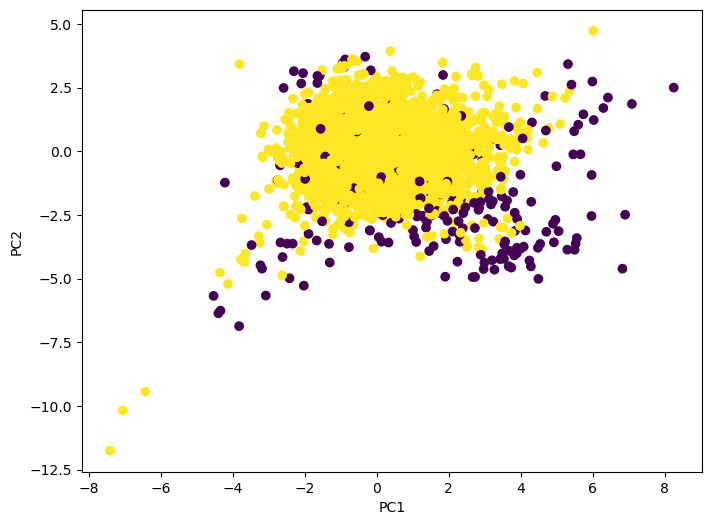

In [15]:
plt.figure(figsize = (8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels)
plt.xlabel("PC1")
plt.ylabel("PC2")

In [16]:
import numpy as np

n_outliers = np.sum(labels == -1)
n_normals = np.sum(labels == 1)

print("Outliers ", n_outliers)
print("normals ", n_normals)

Outliers  249
normals  6667
